# Model Evaluation Exercise 
1. Implement precision-recall curves: plot precision vs recall at different thresholds. Compute the average precision (area under the PR curve).Compare the PR curve to the ROC curve on an imbalanced dataset and explain when each is more informative.
2. Build a nested cross-validation loop: the outer loop evaluates model performance, the inner loop tunes hyperparameters. Use it to compare two models fairly without leaking validation data into the evaluation.
3. Implement a permutation test for model comparison: shuffle the labels, retrain, and measure performance. Repeat 100 times to build a null distribution. Compute the p-value for the observed model performance against this distribution.


### Cheat Sheet

Accuracy
Overall correct

Precision
When model says YES,
how often right?

Recall
Out of all real YES,
how many found?

F1
Balance Precision + Recall

AUC
How well positives ranked above negatives

MSE
Square errors
Punish big mistakes

RMSE
Square-root MSE
Same unit

MAE
Average absolute errors
Less affected by outliers

R²
How much pattern explained
1 = perfect
0 = average prediction
<0 = worse than average

Learning Curve
More data vs score

Validation Curve
Hyperparameter vs score

### 01. Implement precision-recall curves: plot precision vs recall at different thresholds. Compute the average precision (area under the PR curve).Compare the PR curve to the ROC curve on an imbalanced dataset and explain when each is more informative.

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    weights=[0.95, 0.05],   # 95% negative, 5% positive
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [18]:
from sklearn.metrics import r2_score

In [19]:
r2_score(y_test,model.predict(X_test))

0.021219951452509656

In [5]:
y_score = model.predict_proba(X_test)

In [7]:
y_score=y_score[:,1]

In [9]:
from sklearn.metrics import precision_recall_curve

In [10]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

#### Step 3. Precision-Recall curve

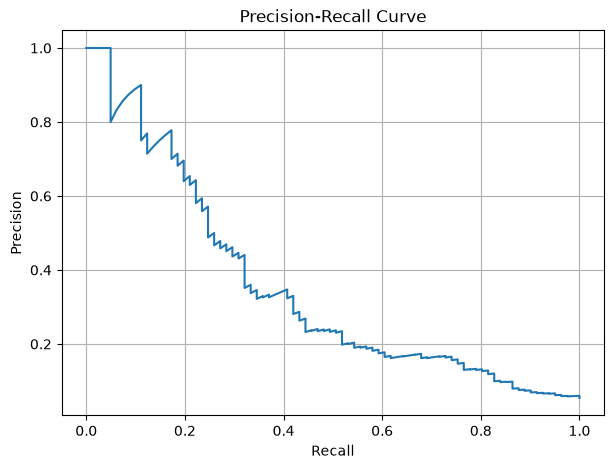

In [15]:
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

#### Step 4. Average Precision (AP)

In [16]:
from sklearn.metrics import average_precision_score
ap = average_precision_score(y_test,y_score)

In [17]:
print("Average Prescesion " , ap)

Average Prescesion  0.3543170667228347


#### Step 5. ROC curve

In [20]:
from sklearn.metrics import roc_curve,roc_auc_score

In [24]:
fpr,tpr,threshold=roc_curve(y_test,y_score)
auc = roc_auc_score(y_test,y_score)

In [27]:
auc

0.804209189222109

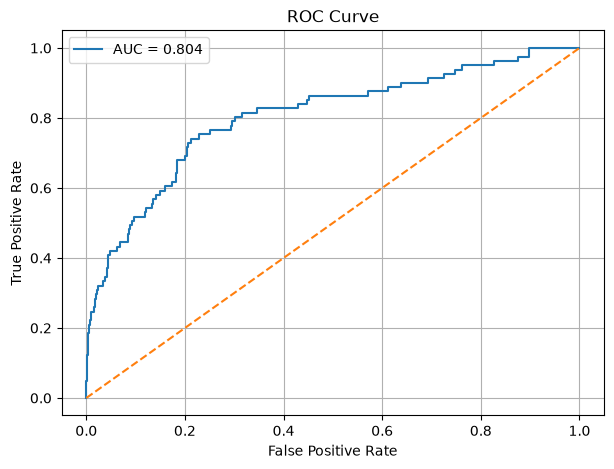

In [28]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

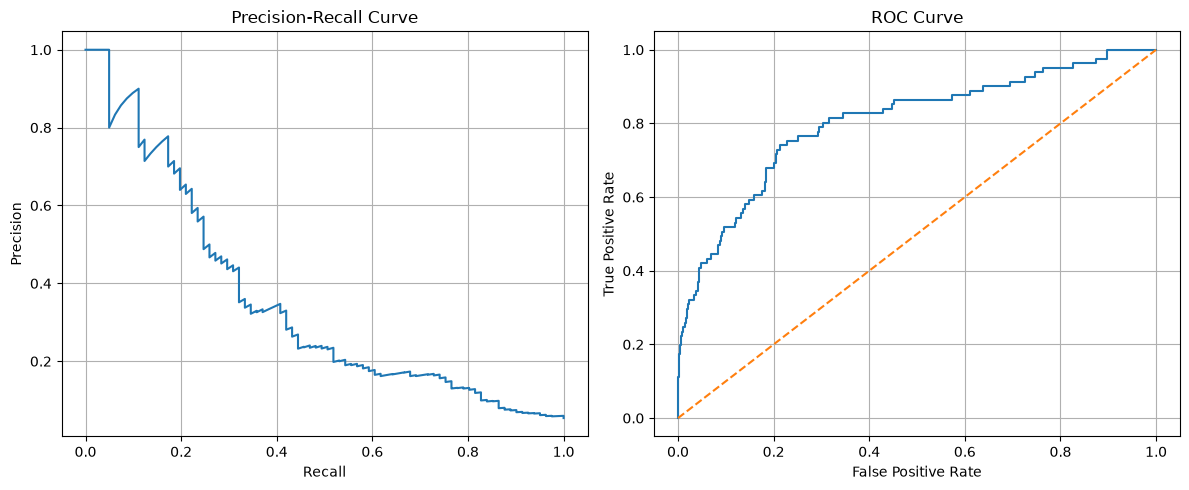

In [29]:
from sklearn.metrics import precision_recall_curve, roc_curve

precision, recall, _ = precision_recall_curve(y_test, y_score)
fpr, tpr, _ = roc_curve(y_test, y_score)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)

plt.tight_layout()
plt.show()

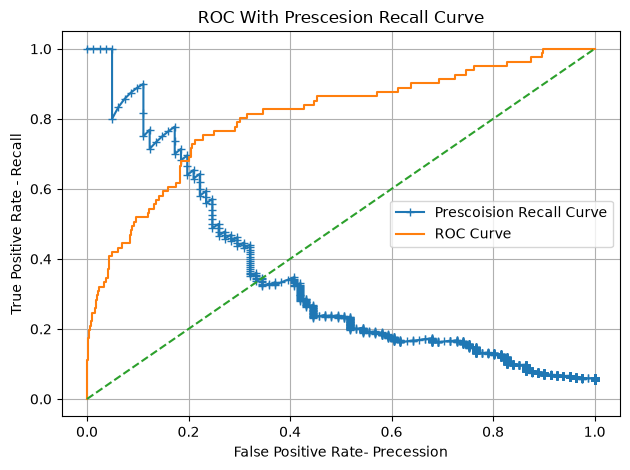

In [33]:

plt.plot(recall, precision,marker="+",label="Prescoision Recall Curve") 
plt.grid(True)

plt.plot(fpr, tpr,label="ROC Curve")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate- Precession")
plt.ylabel("True Positive Rate - Recall")
plt.title("ROC With Prescesion Recall Curve")
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

ROC measures tradeoff between TPR and FPR across thresholds. Suitable when classes roughly balanced.

Precision-Recall curve measures Precision versus Recall across thresholds. Suitable for imbalanced datasets because it focuses on positive class and reveals effect of false positives. Average Precision (AP) summarizes PR curve into one number, analogous to AUC for ROC.

### 02. vallagteche na